# Why Agents need Tools

The example below shows a blog post from a ChatGPT 3 user where they uncovered
an interesting bug when comparing number sizes. In this example the user asks the
model which is larger, 9.11 or 9.9?

In response the model states that 9.11 is larger than 9.9.

[https://community.openai.com/t/why-9-11-is-larger-than-9-9-incredible/869824](https://community.openai.com/t/why-9-11-is-larger-than-9-9-incredible/869824)

<div style="width: 100%; text-align: center;">
  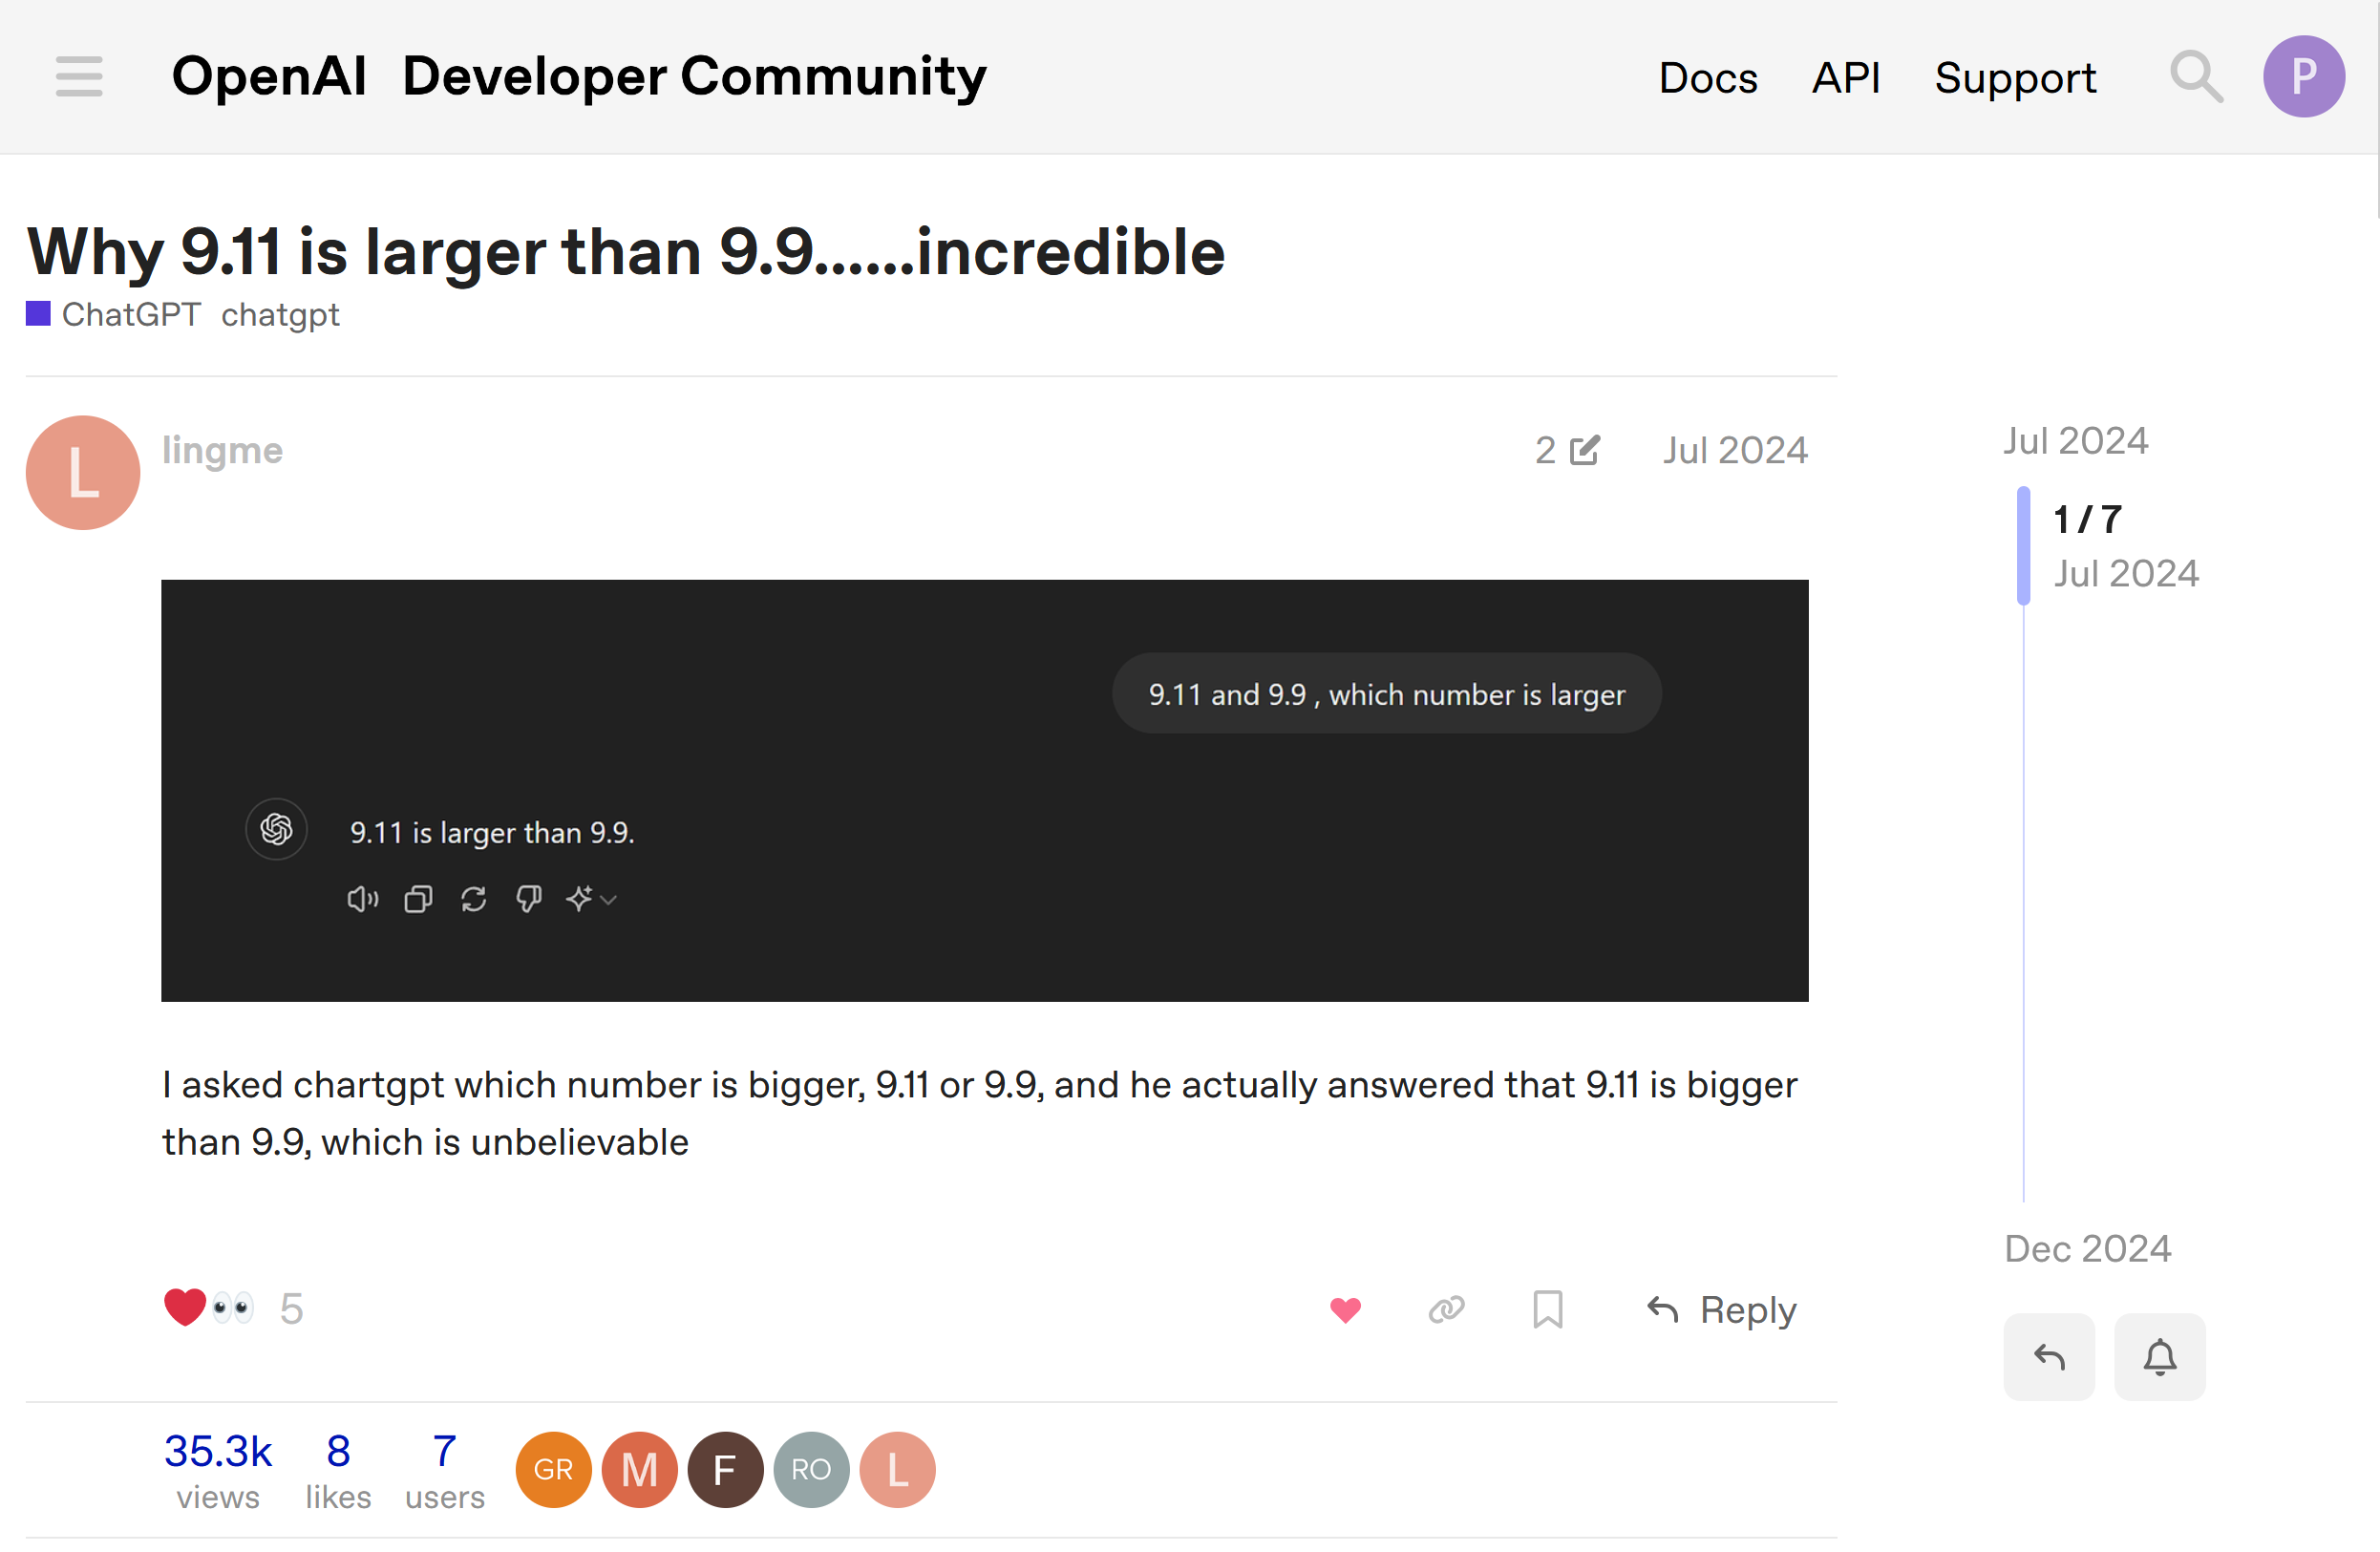
</div>


It is obvious that the model made an error, however what caused this error to occur in the first place?

To understand this, we'll need to review how the model sees text which is done in a process called **tokenization**.

## Tokenization
Tokenization is an essential component of the Natural Language Processing (NLP)
pipeline as it converts strings of human-readable characters into token
representations that are then embedded into vectors for the large language
model.  Raw text does not provide a suitable representation medium for models to
train as it commands a large vocabulary and treats words as distinct units.
Thus, tokenization presents a more efficient representation of the data to the
model as an embedding vector.  Tokenization methods include dividing character
strings into word and subword units, along with indexing frequently occurring
sequences detected using Byte Pair Encoding (BPE).  In order to retain
positional data, methods such as sinusoidal positional encoding or Rotary
Position Embeddings (RoPE) are added to the token embedding vectors.  By
converting the tokens to vector embeddings with positional data, the model is
able to use the semantic and sequential patterns of the input to perform next
token prediction from the representations learned during training.

Here's a nice interactive example showcasing how tokenization works.

[https://platform.openai.com/tokenizer](https://platform.openai.com/tokenizer)

Try inputting the previous prompt, what do you see?

### Byte Pair Encoding
Byte Pair Encoding was first introduced by Philip Gage as a method of data
compression useful in memory-constrained environments due to its fast expansion
routine. The compression routine of the algorithm looks for the most adjacent
byte pairs that occur most frequently within a given pass and replaces the pair
with a byte that doesn't already exist within the data. This repeats until there
are either no more frequent byte pairs or there are no more remaining unused
bytes. The expansion routine is performed over a single pass over the input
file, where byte literals are passed directly to the output buffer and byte
pairs are pushed onto a stack. Within each iteration, if the stack contains
data, the byte there is used as the next input byte; otherwise, the next input
byte is obtained from the input file.

In this exercise, you'll implement the BPE compression and expansion algorithms.

In [1]:
from string import ascii_letters, digits, punctuation
from typing import cast, TypedDict

characters = list(ascii_letters + digits + punctuation)

class BytePairTable(TypedDict):
    character: list[str]
    leftcode: list[str]
    rightcode: list[str | int]

def bpe_compression(input_string: str) -> tuple[BytePairTable, str]:
    byte_pair_table = BytePairTable(
        character = characters.copy(),
        leftcode = characters.copy(),
        rightcode = []
    )

    # Initial rightcode set
    for character in byte_pair_table["character"]:
        if character in input_string:
            byte_pair_table["rightcode"].append(1)
        else:
            byte_pair_table["rightcode"].append(0)

    buffer = input_string
    most_frequent_pair_value = None

    while most_frequent_pair_value is None or most_frequent_pair_value > 1:
        pair_map: dict[str, int] = {}
        buffer_length = len(buffer)

        for character_index in range(1, buffer_length):
            pair = buffer[character_index - 1] + buffer[character_index]

            if pair in pair_map:
                pair_map[pair] += 1
            else:
                pair_map[pair] = 1

        most_frequent_pair_value = max(pair_map.values())

        if most_frequent_pair_value > 1:
            most_frequent_pair_key: str = cast(str, max(pair_map, key=pair_map.get))

            # Find new character assignment.
            first_unused_character_index = next((i for i, v in enumerate(byte_pair_table["rightcode"]) if v == 0), None)
            if first_unused_character_index is None:
                # No more unused characters
                return (byte_pair_table, buffer)

            # Update table
            byte_pair_table["leftcode"][first_unused_character_index] = most_frequent_pair_key[0]
            byte_pair_table["rightcode"][first_unused_character_index] = most_frequent_pair_key[1]
            replacement_character = byte_pair_table["character"][first_unused_character_index]

            buffer = buffer.replace(most_frequent_pair_key, replacement_character)

    return (byte_pair_table, buffer)

def bpe_expansion(byte_pair_table: BytePairTable, buffer: str) -> str:

    input = list(buffer)
    input.reverse()

    stack: list[str] = []
    output_string = ""

    while len(input) > 0 or len(stack) > 0:
        if len(stack) > 0:
            character = stack.pop()
            character_index = byte_pair_table["character"].index(character)
            leftcode_value = byte_pair_table["leftcode"][character_index]
            rightcode_value = byte_pair_table["rightcode"][character_index]

            if rightcode_value == 1:
                output_string += character

            elif isinstance(rightcode_value, str):
                stack.append(rightcode_value)
                stack.append(leftcode_value)

        else:
            character = input.pop()
            stack.append(character)

    return output_string

# Test the BPE implementation
input_string = "ababcabcd"
print(f"input_string: {input_string}")

byte_pair_table, buffer = bpe_compression(input_string)
print(f"buffer: {buffer}")

output_string = bpe_expansion(byte_pair_table, buffer)
print(f"output_string: {output_string}")

input_string: ababcabcd
buffer: effd
output_string: ababcabcd


In [2]:
import unittest

class TestBPE(unittest.TestCase):
    def test_basic_round_trip(self):
        """Test that compression followed by expansion returns the original string."""
        input_string = "ababcabcd"
        byte_pair_table, compressed = bpe_compression(input_string)
        output = bpe_expansion(byte_pair_table, compressed)
        self.assertEqual(output, input_string)
        print("✓ Test 1.1: Basic round trip - PASSED")

    def test_simple_repeated_pair(self):
        """Test compression with a simple repeated pair."""
        input_string = "aaaaaa"
        byte_pair_table, compressed = bpe_compression(input_string)
        self.assertLess(len(compressed), len(input_string))
        output = bpe_expansion(byte_pair_table, compressed)
        self.assertEqual(output, input_string)
        print("✓ Test 1.2: Simple repeated pair - PASSED")

    def test_no_repeated_pairs(self):
        """Test string with no repeated pairs."""
        input_string = "abcdef"
        byte_pair_table, compressed = bpe_compression(input_string)
        self.assertEqual(compressed, input_string)
        output = bpe_expansion(byte_pair_table, compressed)
        self.assertEqual(output, input_string)
        print("✓ Test 1.3: No repeated pairs - PASSED")

    def test_two_characters(self):
        """Test with two characters."""
        input_string = "ab"
        byte_pair_table, compressed = bpe_compression(input_string)
        self.assertEqual(compressed, input_string)
        output = bpe_expansion(byte_pair_table, compressed)
        self.assertEqual(output, input_string)
        print("✓ Test 1.4: Two characters - PASSED")

    def test_multiple_compression_iterations(self):
        """Test that multiple iterations of compression work correctly."""
        input_string = "abababab"
        byte_pair_table, compressed = bpe_compression(input_string)
        self.assertLess(len(compressed), len(input_string))
        output = bpe_expansion(byte_pair_table, compressed)
        self.assertEqual(output, input_string)
        print("✓ Test 1.5: Multiple compression iterations - PASSED")

    def test_nested_pairs(self):
        """Test compression with nested pair patterns."""
        input_string = "aabbccaabbcc"
        byte_pair_table, compressed = bpe_compression(input_string)
        self.assertLess(len(compressed), len(input_string))
        output = bpe_expansion(byte_pair_table, compressed)
        self.assertEqual(output, input_string)
        print("✓ Test 1.6: Nested pairs - PASSED")

    def test_mixed_characters(self):
        """Test with mixed alphanumeric and punctuation."""
        input_string = "Hello!!World!!123123"
        byte_pair_table, compressed = bpe_compression(input_string)
        output = bpe_expansion(byte_pair_table, compressed)
        self.assertEqual(output, input_string)
        print("✓ Test 1.7: Mixed characters - PASSED")

    def test_byte_pair_table_structure(self):
        """Test that the byte pair table has the correct structure."""
        input_string = "aabbcc"
        byte_pair_table, compressed = bpe_compression(input_string)
        self.assertIn("character", byte_pair_table)
        self.assertIn("leftcode", byte_pair_table)
        self.assertIn("rightcode", byte_pair_table)
        self.assertEqual(len(byte_pair_table["character"]), len(byte_pair_table["leftcode"]))
        self.assertEqual(len(byte_pair_table["character"]), len(byte_pair_table["rightcode"]))
        print("✓ Test 1.8: Byte pair table structure - PASSED")

    def test_rightcode_values(self):
        """Test that rightcode values are properly set."""
        input_string = "aabb"
        byte_pair_table, compressed = bpe_compression(input_string)
        char_index_a = byte_pair_table["character"].index("a")
        char_index_b = byte_pair_table["character"].index("b")
        self.assertNotEqual(byte_pair_table["rightcode"][char_index_a], 0)
        self.assertNotEqual(byte_pair_table["rightcode"][char_index_b], 0)
        print("✓ Test 1.9: Rightcode values - PASSED")

    def test_long_repeated_pattern(self):
        """Test with a longer repeated pattern."""
        input_string = "abcabc" * 10
        byte_pair_table, compressed = bpe_compression(input_string)
        self.assertLess(len(compressed), len(input_string))
        output = bpe_expansion(byte_pair_table, compressed)
        self.assertEqual(output, input_string)
        print("✓ Test 1.10: Long repeated pattern - PASSED")

# Run the tests
suite = unittest.TestLoader().loadTestsFromTestCase(TestBPE)
runner = unittest.TextTestRunner(verbosity=0)
result = runner.run(suite)

print(f"\n{'='*50}")
print(f"Tests run: {result.testsRun}")
print(f"Failures: {len(result.failures)}")
print(f"Errors: {len(result.errors)}")
if result.wasSuccessful():
    print("✓ All BPE tests passed!")
else:
    print("✗ Some tests failed")
print(f"{'='*50}")

----------------------------------------------------------------------
Ran 10 tests in 0.000s

OK


✓ Test 1.1: Basic round trip - PASSED
✓ Test 1.8: Byte pair table structure - PASSED
✓ Test 1.10: Long repeated pattern - PASSED
✓ Test 1.7: Mixed characters - PASSED
✓ Test 1.5: Multiple compression iterations - PASSED
✓ Test 1.6: Nested pairs - PASSED
✓ Test 1.3: No repeated pairs - PASSED
✓ Test 1.9: Rightcode values - PASSED
✓ Test 1.2: Simple repeated pair - PASSED
✓ Test 1.4: Two characters - PASSED

Tests run: 10
Failures: 0
Errors: 0
✓ All BPE tests passed!


### Test Your BPE Implementation

Run the tests below to verify your implementation works correctly:

### Subword Neural Machine Translation
Subword Neural Machine Translation is a preprocessing method in which text is
segmented into subword units, specifically useful for encoding out-of-vocabulary
(OOV) words. The approach implements an adapted version of Byte Pair Encoding
(BPE) to first generate the pair table for frequently occurring character
sequences within the training text. This is similar to the pair table seen in
the compressed output that the original BPE produces, but with a slight
adjustment of merging characters rather than bytes to suit the application of
word segmentation. Along with this, the compression routine is set to conclude
after a given number of operations rather than repeating until there are no more
remaining bytes in the text. This provides a tunable `num_operations` parameter
which balances the frequency for complete words and subwords within the
dictionary, improving the coverage of tokens during training. This allows
out-of-vocabulary words to be segmented into combinations of word and subword
tokens.


In [3]:
!pip install subword_nmt

zsh:1: command not found: pip


In [4]:
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE
from subword_nmt.get_vocab import get_vocab
from subword_nmt.segment_char_ngrams import segment_char_ngrams
import io

def snmt_learn_bpe(text, num_operations=10):
    """
    Learn BPE operations from input text and return codes and segmented text.

    Args:
        text: Input text to segment
        num_operations: Number of BPE merge operations to learn

    Returns:
        Tuple of (bpe_codes, segmented_text):
            - bpe_codes: String containing learned BPE merge operations
            - segmented_text: Text segmented with BPE tokens separated by '@@'
    """
    # Learn BPE operations from the input text
    input_file = io.StringIO(text)
    output_file = io.StringIO()

    learn_bpe(input_file, output_file, num_symbols=num_operations)

    # Get the learned codes
    output_file.seek(0)
    codes = output_file.read()

    # Apply learned BPE operations
    output_file.seek(0)
    bpe = BPE(output_file)

    # Segment the text
    segmented = bpe.process_line(text)

    return codes, segmented


def snmt_apply_bpe(text, bpe_codes, vocab=None, vocab_threshold=None):
    """
    Apply pre-learned BPE codes to segment text.

    Args:
        text: Input text to segment
        bpe_codes: String containing BPE merge operations (one per line)
        vocab: Optional dict from snmt_get_vocab. If provided, reverts merges
               that produce out-of-vocabulary tokens.
        vocab_threshold: Optional frequency threshold. Tokens with frequency
                        below this are treated as OOV.

    Returns:
        Segmented text with BPE tokens separated by '@@'
    """
    codes_file = io.StringIO(bpe_codes)

    # Convert vocab dict to set, filtering by threshold if provided
    vocab_set = None
    if vocab is not None:
        if vocab_threshold is not None:
            vocab_set = {word for word, freq in vocab.items() if freq >= vocab_threshold}
        else:
            vocab_set = set(vocab.keys())

    bpe = BPE(codes_file, vocab=vocab_set)
    segmented = bpe.process_line(text)
    return segmented


def snmt_get_vocab(text):
    """
    Extract vocabulary with frequency counts from text.

    Args:
        text: Input text to extract vocabulary from

    Returns:
        Dictionary mapping tokens to their frequency counts
    """
    input_file = io.StringIO(text)
    output_file = io.StringIO()

    get_vocab(input_file, output_file)

    output_file.seek(0)
    vocab = {}
    for line in output_file:
        parts = line.strip().split()
        if len(parts) == 2:
            token, count = parts
            vocab[token] = int(count)
    return vocab


def snmt_segment_char_ngrams(text, n=3, vocab=None):
    """
    Segment text into character n-grams.

    Args:
        text: Input text to segment
        n: Size of character n-grams
        vocab: Optional vocabulary file-like object for shortlisting

    Returns:
        Segmented text with character n-grams
    """
    import argparse

    input_file = io.StringIO(text)
    output_file = io.StringIO()
    vocab_file = vocab if vocab else io.StringIO("")

    args = argparse.Namespace(
        input=input_file,
        output=output_file,
        n=n,
        shortlist=0,
        vocab=vocab_file,
        separator="@@"
    )

    segment_char_ngrams(args)

    output_file.seek(0)
    return output_file.read().strip()

You'll investigate the subword neural machine translation process by running the code below and answering the following questions:

**Question 1:** Before running the code, what tokens would you expect to be added to the vocabulary?

**Question 2:** After running the code, what are some tokens you found in the vocabulary and does that match your expectation?

**Question 3:** Let's take a look at the `num_operations` parameter, keep an eye on `codes` (indicated as "Learned codes:" in the print statement)

- **3a:** Change the `num_operations` to `50`, what do you notice with the vocabulary output?

- **3b:** Now change the `num_operations` to `1`, what do you notice with the vocabulary output?

- **3c:** Why does this happen?

- **3d:** Why use a limit such as `num_operations` as opposed to running this like the compression routine in BPE?

- **3e:** How did the `codes` change while you were changing the `num_operations`. What does `codes` look like what we've seen before in the homework?

**Question 4:** Now set `num_operations` back to `20` and examine the `vocab_threshold` parameter.

- **4a:** Change the `vocab_threshold` to `10`, what do you notice with the token count?

- **4b:** Why does this happen?

In [5]:
import re

# BPE codes will be obtained from this string
train_text = """The quick brown fox jumped over the lazy dog.
I ordered a hamburger from mcdonalds.
I ordered a cheeseburger from mcdonalds.
I ordered a double bacon cheeseburger from burger king.
I ordered a double-double from in-in-out burger.
How much wood could a woodchuck chuck if a woodchuck could chuck wood.
Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
"""

input_text = "I ordered a burger and buffalo wings for Chuck" 

num_operations = 20
vocab_threshold = 2

# Step 1: Learn BPE codes from training text
print("=== Step 1: snmt_learn_bpe ===")
codes, segmented = snmt_learn_bpe(train_text, num_operations=num_operations)
print(f"Segmented: {segmented}")
print(f"Learned codes:\n{codes}")
print(f"Tokens: {len(segmented.split())}")

# Step 2: Get vocabulary from segmented text
print("=== Step 2: snmt_get_vocab ===")
vocab = snmt_get_vocab(segmented)
print(f"Vocabulary: {vocab}")
print(f"Vocab size: {len(vocab)}")

# Step 3: Apply BPE to new text (without vocab constraint)
print("\n=== Step 3a: snmt_apply_bpe (no vocab) ===")
result = snmt_apply_bpe(input_text, codes)
print(f"Input: {input_text}")
print(f"Segmented: {result}")
print(f"Tokens: {len(result.split())}")

# Step 3b: Apply BPE with vocab constraint (reverts OOV merges)
print(f"\n=== Step 3b: snmt_apply_bpe (with vocab, threshold={vocab_threshold}) ===")
result_with_vocab = snmt_apply_bpe(input_text, codes, vocab=vocab, vocab_threshold=vocab_threshold)
print(f"Input: {input_text}")
print(f"Segmented: {result_with_vocab}")
print(f"Tokens: {len(result_with_vocab.split())}")

# The original segmentation can be restored with a simple replacement:
# sed -r 's/(@@ )|(@@ ?$)//g'
print("\n=== Restore original from BPE ===")
restored = re.sub(r"(@@ )|(@@ ?$)", "", segmented)
print(f"Segmented: {segmented}")
print(f"Restored:  {restored}")

=== Step 1: snmt_learn_bpe ===


100%|██████████| 20/20 [00:00<00:00, 29852.70it/s]

Segmented: T@@ h@@ e q@@ u@@ i@@ c@@ k b@@ ro@@ w@@ n f@@ o@@ x j@@ u@@ m@@ p@@ ed o@@ v@@ e@@ r t@@ h@@ e l@@ a@@ z@@ y d@@ o@@ g@@ .@@ 
@@ I o@@ rde@@ red a h@@ a@@ m@@ burge@@ r f@@ rom m@@ c@@ d@@ o@@ n@@ al@@ d@@ s@@ .@@ 
@@ I o@@ rde@@ red a ch@@ e@@ e@@ s@@ e@@ burge@@ r f@@ rom m@@ c@@ d@@ o@@ n@@ al@@ d@@ s@@ .@@ 
@@ I o@@ rde@@ red a d@@ ou@@ b@@ l@@ e b@@ a@@ c@@ o@@ n ch@@ e@@ e@@ s@@ e@@ burge@@ r f@@ rom burge@@ r k@@ i@@ n@@ g@@ .@@ 
@@ I o@@ rde@@ red a d@@ ou@@ b@@ l@@ e@@ -@@ d@@ ou@@ b@@ l@@ e f@@ rom i@@ n@@ -@@ i@@ n@@ -@@ ou@@ t burge@@ r@@ .@@ 
@@ H@@ o@@ w m@@ uc@@ h woo@@ d c@@ ou@@ l@@ d a woo@@ d@@ ch@@ uck ch@@ uck i@@ f a woo@@ d@@ ch@@ uck c@@ ou@@ l@@ d ch@@ uck woo@@ d@@ .@@ 
@@ B@@ u@@ ffalo bu@@ ffalo B@@ u@@ ffalo bu@@ ffalo bu@@ ffalo bu@@ ffalo B@@ u@@ ffalo bu@@ ffal@@ o@@ .

Learned codes:
#version: 0.2
b u
a l
f f
ff al
ffal o</w>
o u
c h
u c
r o
r g
rg e
e d</w>
bu rge
w o
wo o
uc k</w>
ro m</w>
r ed</w>
r d
rd e

Tokens: 201
=== Step 2: snmt_ge

## Exercise 3: Subword Neural Machine Translation (Code)

For this part of the assignment you'll tune the parameters in the code below.

This code contains three parameters to fill in:

1. `TRAIN_TEXT` - training text to learn BPE codes from
2. `INPUT_TEXT` - input text to segment
3. `NUM_OPERATIONS` - number of BPE merge operations

Your goal is to tune these parameters to satisfy the following criteria:

1. `NUM_OPERATIONS` should be at most 20
2. Vocabulary size should be at most 100
3. `'the'` should appear as a complete token
4. `'and'` should appear as a complete token
5. `'a'` should appear as a complete token
6. `INPUT_TEXT` segmentation should produce less than 50 tokens
7. `'er'` should appear in the vocabulary
8. `INPUT_TEXT` should have at least 5 complete tokens and 5 partial tokens
9. `'th'` should appear in the vocabulary
10. `'an'` should appear in the vocabulary

In [6]:
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE
from subword_nmt.get_vocab import get_vocab
import io

def snmt_learn_bpe(text, num_operations=10):
    """Learn BPE operations from input text and return codes and segmented text."""
    input_file = io.StringIO(text)
    output_file = io.StringIO()
    learn_bpe(input_file, output_file, num_symbols=num_operations)
    
    output_file.seek(0)
    codes = output_file.read()
    
    output_file.seek(0)
    bpe = BPE(output_file)
    segmented = bpe.process_line(text)
    
    return codes, segmented

def snmt_apply_bpe(text, bpe_codes):
    """Apply pre-learned BPE codes to segment text."""
    codes_file = io.StringIO(bpe_codes)
    bpe = BPE(codes_file)
    segmented = bpe.process_line(text)
    return segmented

def snmt_get_vocab(text):
    """Extract vocabulary with frequency counts from text."""
    input_file = io.StringIO(text)
    output_file = io.StringIO()
    get_vocab(input_file, output_file)
    
    output_file.seek(0)
    vocab = {}
    for line in output_file:
        parts = line.strip().split()
        if len(parts) == 2:
            token, count = parts
            vocab[token] = int(count)
    return vocab

TRAIN_TEXT = """
the cat was cleaner than a dog and the bird was higher than a cow.
he found a cat and a dog in the barn.
an egg is smaller than another ant.
the dog howled at the moon.
he threw a ball at he.
"""

INPUT_TEXT = "the dog howled at the moon" 

NUM_OPERATIONS = 20  # Adjust number of operations

# Step 1: Learn BPE codes from training text
print("=== Step 1: snmt_learn_bpe ===")
codes, segmented = snmt_learn_bpe(TRAIN_TEXT, num_operations=NUM_OPERATIONS)
print(f"Segmented: {segmented}")
print(f"Tokens: {len(segmented.split())}")

# Step 2: Get vocabulary from segmented text
print("\n=== Step 2: snmt_get_vocab ===")
vocab = snmt_get_vocab(segmented)
print(f"Vocabulary: {vocab}")
print(f"Vocab size: {len(vocab)}")

# Step 3: Apply BPE to input text
print("\n=== Step 3: snmt_apply_bpe ===")
applied = snmt_apply_bpe(INPUT_TEXT, codes)
tokens = applied.split()
complete_tokens = sum(1 for t in tokens if not t.endswith("@@"))
partial_tokens = sum(1 for t in tokens if t.endswith("@@"))
print(f"Input: {INPUT_TEXT}")
print(f"Segmented: {applied}")
print(f"Tokens: {len(tokens)}")
print(f"Complete tokens: {complete_tokens}")
print(f"Partial tokens: {partial_tokens}")

=== Step 1: snmt_learn_bpe ===


 90%|█████████ | 18/20 [00:00<00:00, 38956.38it/s]

Segmented: 
the cat was c@@ le@@ an@@ er than a dog and the b@@ i@@ r@@ d was h@@ i@@ g@@ h@@ er than a c@@ ow@@ .@@ 
@@ he f@@ o@@ u@@ n@@ d a cat and a dog i@@ n the ba@@ r@@ n@@ .@@ 
@@ an e@@ g@@ g i@@ s s@@ m@@ a@@ l@@ l@@ er than an@@ o@@ th@@ er an@@ t@@ .@@ 
@@ the dog h@@ ow@@ le@@ d at the m@@ o@@ o@@ n@@ .@@ 
@@ he th@@ r@@ e@@ w a ba@@ l@@ l at h@@ e@@ .

Tokens: 95

=== Step 2: snmt_get_vocab ===
Vocabulary: {'the': 5, 'a': 5, 'er': 4, 'i@@': 4, 'h@@': 4, '.@@': 4, '@@': 4, 'o@@': 4, 'an@@': 3, 'than': 3, 'dog': 3, 'r@@': 3, 'd': 3, 'n@@': 3, 'e@@': 3, 'l@@': 3, 'cat': 2, 'was': 2, 'c@@': 2, 'le@@': 2, 'and': 2, 'g@@': 2, 'ow@@': 2, 'he': 2, 'ba@@': 2, 'm@@': 2, 'th@@': 2, 'at': 2, 'b@@': 1, 'f@@': 1, 'u@@': 1, 'n': 1, 'an': 1, 'g': 1, 's': 1, 's@@': 1, 'a@@': 1, 't@@': 1, 'w': 1, 'l': 1, '.': 1}
Vocab size: 41

=== Step 3: snmt_apply_bpe ===
Input: the dog howled at the moon
Segmented: the dog h@@ ow@@ le@@ d at the m@@ o@@ o@@ n
Tokens: 12
Complete tokens: 6
Partial toke

In [7]:
import unittest

class TestSNMT(unittest.TestCase):
    def test_num_operations_limit(self):
        """NUM_OPERATIONS should be at most 20."""
        self.assertLessEqual(NUM_OPERATIONS, 20, f"NUM_OPERATIONS {NUM_OPERATIONS} exceeds 20")
        print("✓ Test 2.1: NUM_OPERATIONS limit - PASSED")

    def test_vocab_size_max(self):
        """Vocabulary Size: vocab size should be at most 100."""
        codes, segmented = snmt_learn_bpe(TRAIN_TEXT, num_operations=NUM_OPERATIONS)
        vocab = snmt_get_vocab(segmented)
        vocab_size = len(vocab)
        self.assertLessEqual(vocab_size, 100, f"Vocab size {vocab_size} exceeds 100")
        print("✓ Test 2.2: Vocabulary size - PASSED")

    def test_complete_token_the(self):
        """Complete Token: 'the' should appear as a complete token."""
        codes, segmented = snmt_learn_bpe(TRAIN_TEXT, num_operations=NUM_OPERATIONS)
        tokens = segmented.split()
        self.assertIn("the", tokens, "'the' not found as a complete token")
        print("✓ Test 2.3: Complete token 'the' - PASSED")

    def test_complete_token_and(self):
        """Complete Token: 'and' should appear as a complete token."""
        codes, segmented = snmt_learn_bpe(TRAIN_TEXT, num_operations=NUM_OPERATIONS)
        tokens = segmented.split()
        self.assertIn("and", tokens, "'and' not found as a complete token")
        print("✓ Test 2.4: Complete token 'and' - PASSED")

    def test_complete_token_a(self):
        """Complete Token: 'a' should appear as a complete token."""
        codes, segmented = snmt_learn_bpe(TRAIN_TEXT, num_operations=NUM_OPERATIONS)
        tokens = segmented.split()
        self.assertIn("a", tokens, "'a' not found as a complete token")
        print("✓ Test 2.5: Complete token 'a' - PASSED")

    def test_input_text_segmentation(self):
        """INPUT_TEXT segmentation should produce less than 50 tokens."""
        codes, _ = snmt_learn_bpe(TRAIN_TEXT, num_operations=NUM_OPERATIONS)
        applied = snmt_apply_bpe(INPUT_TEXT, codes)
        token_count = len(applied.split())
        self.assertLess(token_count, 50, f"INPUT_TEXT token count {token_count} is not less than 50")
        print("✓ Test 2.6: INPUT_TEXT segmentation - PASSED")

    def test_subword_er(self):
        """Subword: 'er' should appear in vocabulary."""
        codes, segmented = snmt_learn_bpe(TRAIN_TEXT, num_operations=NUM_OPERATIONS)
        vocab = snmt_get_vocab(segmented)
        has_er = "er" in vocab or "er@@" in vocab
        self.assertTrue(has_er, "'er' not found in vocabulary")
        print("✓ Test 2.7: Subword 'er' - PASSED")

    def test_input_text_complete_and_partial_tokens(self):
        """INPUT_TEXT should have at least 5 complete tokens and 5 partial tokens."""
        codes, _ = snmt_learn_bpe(TRAIN_TEXT, num_operations=NUM_OPERATIONS)
        applied = snmt_apply_bpe(INPUT_TEXT, codes)
        tokens = applied.split()
        complete_tokens = sum(1 for t in tokens if not t.endswith("@@"))
        partial_tokens = sum(1 for t in tokens if t.endswith("@@"))
        self.assertGreaterEqual(complete_tokens, 5, f"INPUT_TEXT has only {complete_tokens} complete tokens (need 5)")
        self.assertGreaterEqual(partial_tokens, 5, f"INPUT_TEXT has only {partial_tokens} partial tokens (need 5)")
        print("✓ Test 2.8: Complete and partial tokens - PASSED")

    def test_subword_th(self):
        """Subword: 'th' should appear in vocabulary."""
        codes, segmented = snmt_learn_bpe(TRAIN_TEXT, num_operations=NUM_OPERATIONS)
        vocab = snmt_get_vocab(segmented)
        has_th = "th" in vocab or "th@@" in vocab
        self.assertTrue(has_th, "'th' not found in vocabulary")
        print("✓ Test 2.9: Subword 'th' - PASSED")

    def test_subword_an(self):
        """Subword: 'an' should appear in vocabulary."""
        codes, segmented = snmt_learn_bpe(TRAIN_TEXT, num_operations=NUM_OPERATIONS)
        vocab = snmt_get_vocab(segmented)
        has_an = "an" in vocab or "an@@" in vocab
        self.assertTrue(has_an, "'an' not found in vocabulary")
        print("✓ Test 2.10: Subword 'an' - PASSED")

# Run the tests
suite = unittest.TestLoader().loadTestsFromTestCase(TestSNMT)
runner = unittest.TextTestRunner(verbosity=0)
result = runner.run(suite)

print(f"\n{'='*50}")
print(f"Tests run: {result.testsRun}")
print(f"Failures: {len(result.failures)}")
print(f"Errors: {len(result.errors)}")
if result.wasSuccessful():
    print("✓ All SNMT tests passed!")
else:
    print("✗ Some tests failed")
print(f"{'='*50}")

 90%|█████████ | 18/20 [00:00<00:00, 67893.41it/s]


✓ Test 2.5: Complete token 'a' - PASSED


 90%|█████████ | 18/20 [00:00<00:00, 95325.09it/s]


✓ Test 2.4: Complete token 'and' - PASSED


 90%|█████████ | 18/20 [00:00<00:00, 109258.28it/s]


...

✓ Test 2.7: Subword 'er' - PASSED


 90%|█████████ | 18/20 [00:00<00:00, 113359.57it/s]


✓ Test 2.9: Subword 'th' - PASSED


 90%|█████████ | 18/20 [00:00<00:00, 115439.56it/s]
----------------------------------------------------------------------
Ran 10 tests in 0.009s

OK


✓ Test 2.2: Vocabulary size - PASSED

Tests run: 10
Failures: 0
Errors: 0
✓ All SNMT tests passed!


### Test Your SNMT Implementation

Run the tests below to verify your parameter tuning satisfies all criteria: